# Chapter 1 — Computer Vision Python Lab (OpenCV)

This notebook guides beginners through the **core concepts of Chapter 1** using **OpenCV** (`cv2`).  
We use a **real grayscale image** so the effect of each operation is clearly visible.

**Main topics:** image as a matrix, sampling, quantization, clipping, brightness/contrast, normalization, gamma correction, LUT, global/local statistics, entropy, and basic color spaces.

> **Tip (Colab):** Run cells in order. If you want to keep your work, use **File → Save a copy in Drive**.


## 1) Install and import libraries

In [1]:
# If you are on Google Colab, run this cell once.
!pip -q install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap


## 2) Helper functions (display, clipping, normalization)

In [2]:
def show_gray(I, title="", size=6):
    plt.figure(figsize=(size, size))
    plt.imshow(I, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_rgb(img_bgr, title="", size=6):
    # OpenCV loads color images as BGR; matplotlib expects RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(size, size))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

def clip_uint8(x):
    return np.clip(np.round(x), 0, 255).astype(np.uint8)

def normalize_01(I):
    return I.astype(np.float32) / 255.0

def denormalize_255(I01):
    return clip_uint8(255.0 * I01)

def tint_channel(channel, color_rgb):
    '''
    Visualize a single channel using a chosen tint color.
    channel: 2D uint8 image in [0,255]
    color_rgb: tuple/list such as (0,255,255) for cyan
    '''
    ch = channel.astype(np.float32) / 255.0
    color = np.array(color_rgb, dtype=np.float32) / 255.0
    out = ch[..., None] * color[None, None, :]
    return np.clip(out, 0, 1)

def show_four_images_horizontal(images, titles, suptitle=None, figsize=(18,5), cmaps=None, vmins=None, vmaxs=None):
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    for i, ax in enumerate(axes):
        img = images[i]
        cmap = None if cmaps is None else cmaps[i]
        vmin = None if vmins is None else vmins[i]
        vmax = None if vmaxs is None else vmaxs[i]
        if cmap is None:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(titles[i], fontsize=16)
        ax.axis("off")
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=22)
    plt.tight_layout()
    plt.show()


## 3) Load your flower image (grayscale)

In [ ]:
# Option A: if your image file is already in the working directory, set its name here.
# Example: gray.png
image_path = "gray.png"

# If the file is not found, use Colab upload (Option B).
if not Path(image_path).exists():
    print(f"File '{image_path}' not found.")
    print("If you are in Colab, run the next cell to upload your image.")
else:
    I = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    print("Loaded:", image_path)
    show_gray(I, "Flower image I[m,n] (grayscale)")
    print("Shape:", I.shape, "| dtype:", I.dtype, "| min/max:", int(I.min()), int(I.max()))


### Option B (Colab): upload your image if needed

In [ ]:
# Run this cell ONLY if the previous cell says the file was not found.
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
I = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

show_gray(I, "Flower image I[m,n] (uploaded grayscale)")
print("Loaded:", filename)
print("Shape:", I.shape, "| dtype:", I.dtype, "| min/max:", int(I.min()), int(I.max()))


## 4) Sampling (downsampling)

In [ ]:
def sample_down(I, step=2):
    # Keep one pixel every 'step' in both directions
    return I[::step, ::step]

step = 4
I_s = sample_down(I, step=step)
show_gray(I_s, f"Sampled image (keep 1 pixel every {step})")
print("Original:", I.shape, "-> Sampled:", I_s.shape)


### Visualization: resize back using nearest-neighbor

In [ ]:
I_vis = cv2.resize(I_s, (I.shape[1], I.shape[0]), interpolation=cv2.INTER_NEAREST)
show_gray(I_vis, "Visualization: sampled then resized (nearest-neighbor)")


## 5) Quantization (reduce gray levels)

In [ ]:
def quantize_levels(I, L=16):
    # Quantize to L levels (L >= 2), output in [0,255]
    I = I.astype(np.float32)
    q = np.round((L - 1) * I / 255.0)
    Iq = 255.0 * q / (L - 1)
    return clip_uint8(Iq)

I_q16 = quantize_levels(I, L=16)  # ~4 bits
I_q4  = quantize_levels(I, L=4)   # ~2 bits

show_gray(I_q16, "Quantized image (L=16 levels)")
show_gray(I_q4,  "Quantized image (L=4 levels)")


## 6) Clipping (saturation) + Brightness

In [ ]:
def add_brightness(I, b):
    return clip_uint8(I.astype(np.float32) + b)

I_bright = add_brightness(I, 80)
I_dark   = add_brightness(I, -80)

show_gray(I_bright, "Brightness +80 (clipping may occur)")
show_gray(I_dark,   "Brightness -80")
print("Bright min/max:", int(I_bright.min()), int(I_bright.max()))


## 7) Contrast (intensity gain)

In [ ]:
def change_contrast(I, c):
    return clip_uint8(c * I.astype(np.float32))

I_c_high = change_contrast(I, 1.6)
I_c_low  = change_contrast(I, 0.6)

show_gray(I_c_high, "Contrast c=1.6 (range stretches; clipping may occur)")
show_gray(I_c_low,  "Contrast c=0.6 (range compresses)")


## 8) Normalization

In [ ]:
I01 = normalize_01(I)
print("Normalized range:", float(I01.min()), "to", float(I01.max()))

# Min–max normalization to [0,1]
I_mm = (I.astype(np.float32) - I.min()) / (I.max() - I.min() + 1e-12)
show_gray(denormalize_255(I_mm), "Min–max normalized then scaled back")


## 9) Gamma correction (nonlinear mapping)

In [ ]:
def gamma_correct(I, gamma=1.0):
    I01 = normalize_01(I)
    out = np.power(I01, gamma)
    return denormalize_255(out)

show_gray(gamma_correct(I, 0.5), "Gamma = 0.5 (brighter shadows)")
show_gray(gamma_correct(I, 2.0), "Gamma = 2.0 (darker shadows)")


## 10) LUT (Look-Up Table) in OpenCV

In [ ]:
# OpenCV LUT expects a 256x1 table of uint8
lut_invert = np.array([255 - k for k in range(256)], dtype=np.uint8).reshape(256, 1)
I_inv = cv2.LUT(I, lut_invert)
show_gray(I_inv, "LUT example: inversion")

gamma = 0.6
lut_gamma = clip_uint8(255 * (np.arange(256)/255.0) ** gamma).reshape(256, 1)
I_g = cv2.LUT(I, lut_gamma)
show_gray(I_g, f"LUT example: gamma LUT (γ={gamma})")


## 11) Global statistics (mean, variance, std)

In [ ]:
mu = float(I.mean())
var = float(((I.astype(np.float32) - mu)**2).mean())  # uses 1/(MN)
std = float(np.sqrt(var))

print(f"Mean μ = {mu:.2f}")
print(f"Variance σ^2 = {var:.2f}")
print(f"Std σ = {std:.2f}")


## 12) Local statistics and texture (local standard deviation)

In [ ]:
k = 21  # window size (odd)
I_f = I.astype(np.float32)

muL = cv2.blur(I_f, (k, k))
mu2L = cv2.blur(I_f**2, (k, k))
varL = np.maximum(mu2L - muL**2, 0)
stdL = np.sqrt(varL)

show_gray(clip_uint8(muL), f"Local mean (window {k}×{k})")

# Texture strength ~ local std (normalized for display)
std_vis = stdL / (stdL.max() + 1e-12)
show_gray(denormalize_255(std_vis), "Texture map (local standard deviation)")


## 13) Entropy (from histogram)

In [ ]:
def entropy(I, L=256):
    hist = cv2.calcHist([I],[0],None,[L],[0,256]).flatten()
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

print("Entropy H =", entropy(I), "bits")


## 14) Color spaces with OpenCV (BGR/RGB, HSV, YCbCr, CMY)

OpenCV loads color images as **BGR** by default.  
We will work with a **color** version of our "flower" image. If you do not have one,
you can upload any color image.

**Conversions used:**
- BGR → HSV: `cv2.COLOR_BGR2HSV`
- BGR → YCrCb: `cv2.COLOR_BGR2YCrCb`  
  (OpenCV uses **YCrCb** ordering; it is closely related to YCbCr.)
- RGB → CMY: computed as `255 - RGB`

The following visualizations are arranged **horizontally** so that you can compare the components directly.


In [ ]:
# Option A: load a color image from the working directory
# Replace by your color filename if you have one, e.g., 'flower_color.jpg'
color_image_path = "flower_color.jpg"

if not Path(color_image_path).exists():
    print(f"File '{color_image_path}' not found.")
    print("If you are in Colab, run the next cell to upload a COLOR image.")
    print("Otherwise, we will create a 3-channel image from the grayscale flower image.")
    img_bgr = cv2.cvtColor(I, cv2.COLOR_GRAY2BGR)
else:
    img_bgr = cv2.imread(color_image_path, cv2.IMREAD_COLOR)
    print("Loaded:", color_image_path)

show_rgb(img_bgr, "Color image (BGR displayed as RGB)")


### Option B (Colab): upload a COLOR image if needed

Saving 3.jpg to 3.jpg


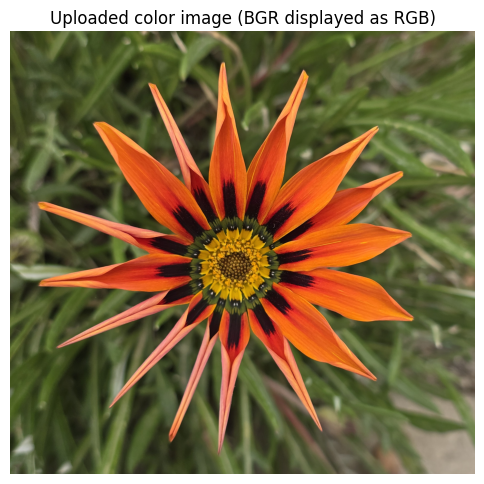

Loaded: 3.jpg | shape: (3386, 3558, 3) | dtype: uint8


In [4]:
# Run this cell if you want to upload a COLOR image (recommended).
from google.colab import files
uploaded_color = files.upload()

color_filename = list(uploaded_color.keys())[0]
img_bgr = cv2.imread(color_filename, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise ValueError("OpenCV could not read the uploaded file as a color image. Try another file.")

show_rgb(img_bgr, "Uploaded color image (BGR displayed as RGB)")
print("Loaded:", color_filename, "| shape:", img_bgr.shape, "| dtype:", img_bgr.dtype)


### 14.1 HSV color space

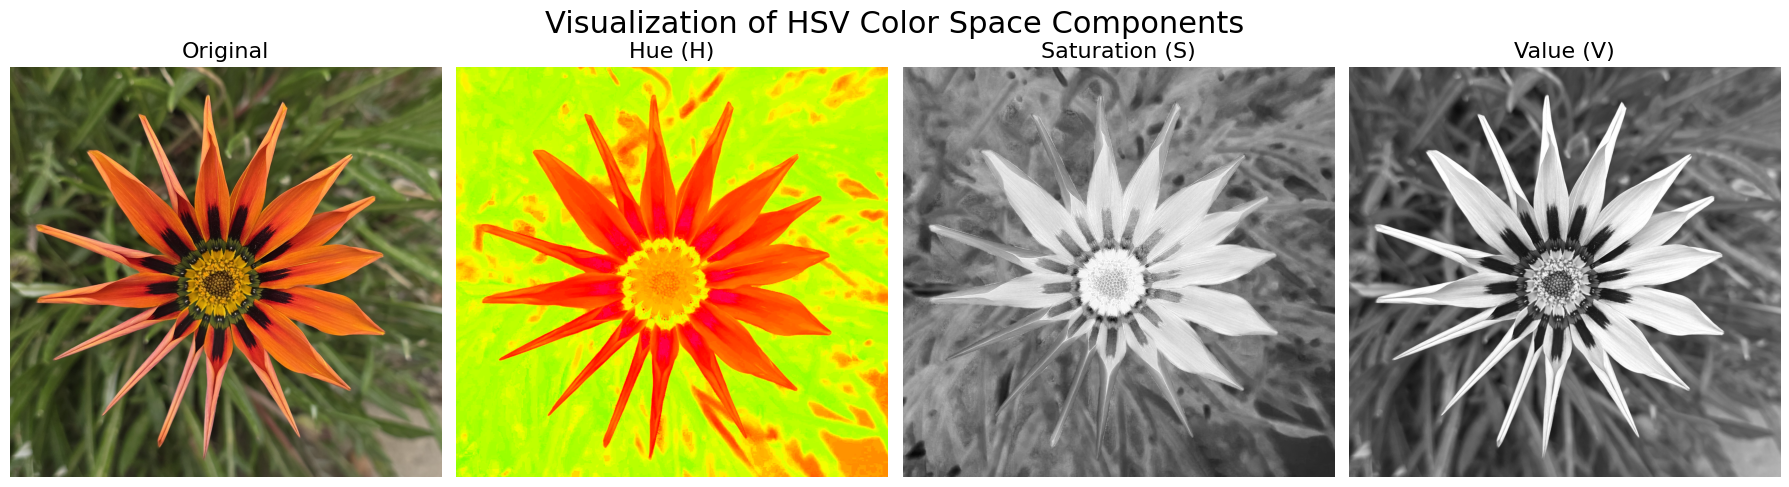

In [5]:
# BGR -> HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# Original image in RGB for matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

show_four_images_horizontal(
    images=[img_rgb, H, S, V],
    titles=["Original", "Hue (H)", "Saturation (S)", "Value (V)"],
    suptitle="Visualization of HSV Color Space Components",
    cmaps=[None, "hsv", "gray", "gray"],
    vmins=[None, 0, 0, 0],
    vmaxs=[None, 179, 255, 255]
)


### 14.2 YCbCr color space

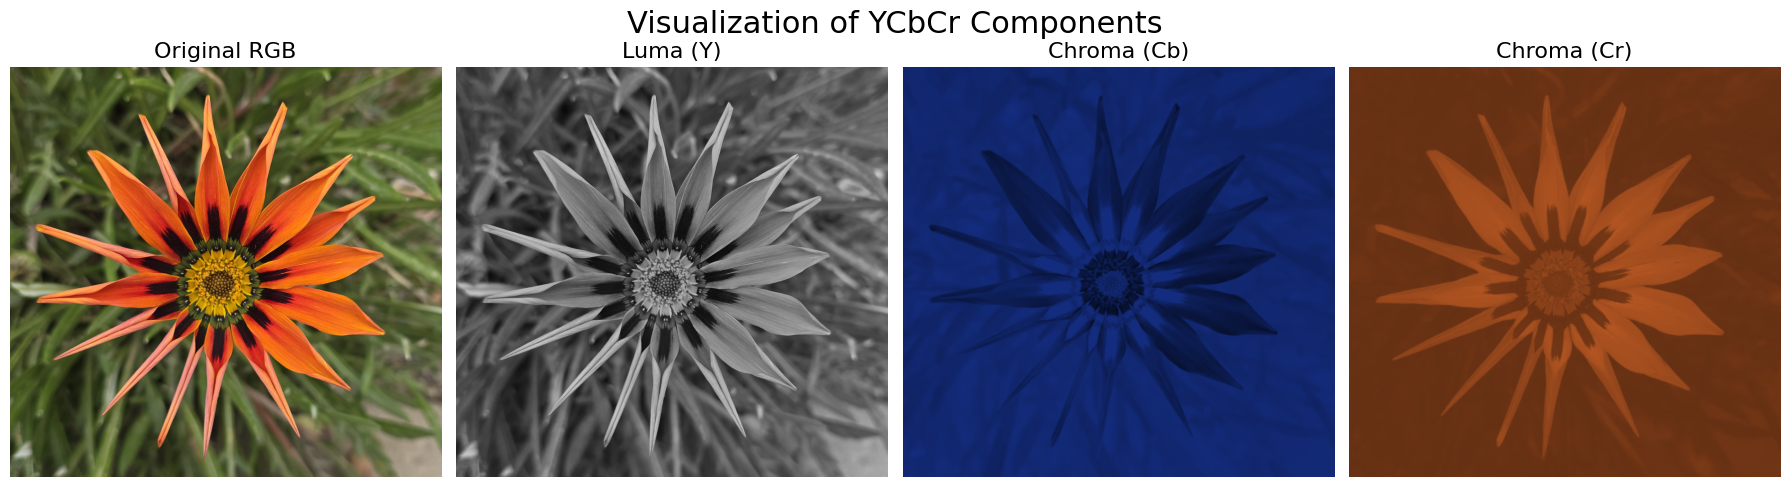

In [6]:
# BGR -> YCrCb (OpenCV ordering), then display as Y, Cb, Cr
ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)

Cb_vis = tint_channel(Cb, (40, 90, 255))      # blue tint
Cr_vis = tint_channel(Cr, (210, 100, 40))     # orange/red tint

show_four_images_horizontal(
    images=[img_rgb, Y, Cb_vis, Cr_vis],
    titles=["Original RGB", "Luma (Y)", "Chroma (Cb)", "Chroma (Cr)"],
    suptitle="Visualization of YCbCr Components",
    cmaps=[None, "gray", None, None],
    vmins=[None, 0, None, None],
    vmaxs=[None, 255, None, None]
)


### 14.3 CMY color space

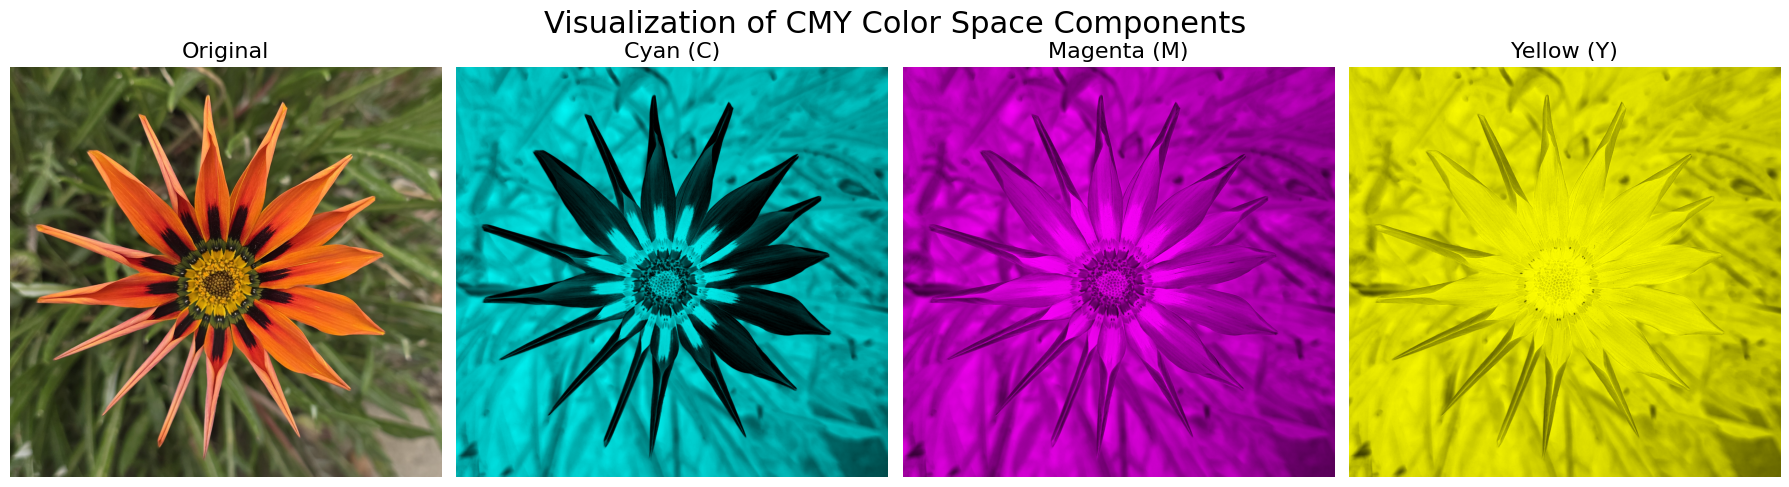

In [7]:
# RGB -> CMY
R, G, B = cv2.split(img_rgb)
C = 255 - R
M = 255 - G
Yc = 255 - B   # Y channel in CMY; use Yc name to avoid confusion with Y of YCbCr

C_vis = tint_channel(C, (0, 255, 255))       # cyan
M_vis = tint_channel(M, (255, 0, 255))       # magenta
Y_vis = tint_channel(Yc, (255, 255, 0))      # yellow

show_four_images_horizontal(
    images=[img_rgb, C_vis, M_vis, Y_vis],
    titles=["Original", "Cyan (C)", "Magenta (M)", "Yellow (Y)"],
    suptitle="Visualization of CMY Color Space Components"
)
